<a href="https://colab.research.google.com/github/ketanchawda-02/Pytorch_Learning_01/blob/main/Pt_basic01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# LINK of YOU TUBE VIDEO:  https://www.youtube.com/watch?v=r1bquDz5GGA&t=987s

import torch
import torch.nn as nn


In [ ]:
d1=torch.tensor([[1.,2.,3.],[4.,5.,6.]])
d2=torch.arange(0,6,1).reshape(2,3)
d3=torch.tensor(d2)
print(d1, d1.device,d1.dtype, d1.shape)
print(d2)
print(d3, d3.device, d3.dtype, d3.shape)

tensor([[1., 2., 3.],
        [4., 5., 6.]]) cpu torch.float32 torch.Size([2, 3])
tensor([[0, 1, 2],
        [3, 4, 5]])
tensor([[0, 1, 2],
        [3, 4, 5]]) cpu torch.int64 torch.Size([2, 3])


/tmp/ipykernel_4007/477091901.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  d3=torch.tensor(d2)


In [ ]:
print(d1,d1.mean(dim=0),d1.mean(dim=1), d1.median)

tensor([[1., 2., 3.],
        [4., 5., 6.]]) tensor([2.5000, 3.5000, 4.5000]) tensor([2., 5.]) <built-in method median of Tensor object at 0x79ad05f893b0>


In [ ]:
# making tensor
d4=torch.randn(3,3)
d4=torch.tensor(d4, requires_grad=True)

/tmp/ipykernel_4007/3520907984.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  d4=torch.tensor(d4, requires_grad=True)


In [ ]:
# THIS IS MAKING A SMALL FORWARD PASS in Pytorch  :: y= 2*X+1 >> y=W*X + b

# Batch has 10 datapoints
N=10
# Each datapoint has 1-input and 1-O/p
D_in=1
D_out=1

X=torch.randn(N,D_in)
true_W=torch.tensor([[2.]])
true_b=torch.tensor(1.)
y_true = X @ true_W + true_b + torch.randn(N, D_out)*0.1  # Adding Little noise here
print(f"True value of W={true_W}")
print(f"True value of b={true_b}")

True value of W=tensor([[2.]])
True value of b=1.0


In [ ]:
W = torch.randn(D_in, D_out, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print(f"Initial weight W = {W}")
print(f"Initial bias b = {b}")

Initial weight W = tensor([[0.0223]], requires_grad=True)
Initial bias b = tensor([0.8172], requires_grad=True)


In [ ]:
y_hat = X @ W +b
print(y_hat)

tensor([[0.8195],
        [0.8470],
        [0.8206],
        [0.8012],
        [0.8143],
        [0.7734],
        [0.7877],
        [0.8102],
        [0.8188],
        [0.8059]], grad_fn=<AddBackward0>)


In [ ]:
# this is MSE loss
error = (y_hat - y_true)
sqr_error = error**2
loss = sqr_error.mean()

print(loss)

print(W.grad)
print(b.grad)


tensor(3.0991, grad_fn=<MeanBackward0>)
None
None


In [ ]:
loss.backward()
print(W.grad)
print(b.grad)

tensor([[-3.1905]])
tensor([0.8865])


In [ ]:
# Hyperparameters
lr = 0.05
epochs=150

# Inintializing Parameter like W and b
W = torch.randn(D_in, D_out, requires_grad=True)
b = torch.randn(1, requires_grad=True)

for epoch in range (epochs):
  #Forward-pass and loss:
  y_hat = X @ W + b
  loss = ((y_hat - y_true)**2).mean()

  # backward loss
  loss.backward()

  with torch.no_grad():
    W -= lr * W.grad;
    b -= lr * b.grad;

  print(f"Epoch-{epoch+1}/{epochs}: loss = {loss}, W_grad = {W.grad}, b_grad = {b.grad}")
  # Zero Greadients
  W.grad.zero_(), b.grad.zero_()

print(f"Learned Parameters: W = {W}, b = {b}")
print(f"True Parameters: W = {true_W}, b = {true_b}")


Epoch-1/150: loss = 4.810207843780518, W_grad = tensor([[-3.6874]]), b_grad = tensor([-0.1397])
Epoch-2/150: loss = 4.156903266906738, W_grad = tensor([[-3.3848]]), b_grad = tensor([-0.2464])
Epoch-3/150: loss = 3.6036739349365234, W_grad = tensor([[-3.1109]]), b_grad = tensor([-0.3326])
Epoch-4/150: loss = 3.133005142211914, W_grad = tensor([[-2.8626]]), b_grad = tensor([-0.4012])
Epoch-5/150: loss = 2.7308249473571777, W_grad = tensor([[-2.6372]]), b_grad = tensor([-0.4548])
Epoch-6/150: loss = 2.3857710361480713, W_grad = tensor([[-2.4324]]), b_grad = tensor([-0.4956])
Epoch-7/150: loss = 2.088618040084839, W_grad = tensor([[-2.2460]]), b_grad = tensor([-0.5257])
Epoch-8/150: loss = 1.8318380117416382, W_grad = tensor([[-2.0761]]), b_grad = tensor([-0.5467])
Epoch-9/150: loss = 1.6092536449432373, W_grad = tensor([[-1.9210]]), b_grad = tensor([-0.5600])
Epoch-10/150: loss = 1.4157665967941284, W_grad = tensor([[-1.7793]]), b_grad = tensor([-0.5669])
Epoch-11/150: loss = 1.2471472024

In [1]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [ ]:
# NOW WE ARE MAKING OUR MODEL WITH NN

# >> We have learned the clay to brick. Now we use Bricks build by supplier to make wall.

# THIS creates parameter by itself.
linear_layer = nn.Linear(D_in,D_out)
y_hat_nn = linear_layer(X)


print(y_hat_nn)
print(f'{linear_layer.weight}\n{linear_layer.bias}\n')

tensor([[-0.0771],
        [ 0.0443],
        [-0.0725],
        [-0.1581],
        [-0.1001],
        [-0.2808],
        [-0.2177],
        [-0.1181],
        [-0.0805],
        [-0.1373]], grad_fn=<AddmmBackward0>)
Parameter containing:
tensor([[0.0983]], requires_grad=True)
Parameter containing:
tensor([-0.0876], requires_grad=True)



In [ ]:
# Non-linearities inclusion

softmax=nn.Softmax(dim=-1)
logits = torch.tensor([[1.0, 3., 4., 0.5, 1.5],[-1., -2.5, 2.5, 1.,3.]])
probabilities = softmax(logits)
p = probabilities.sum(dim=1)

print(probabilities)
print(p)

tensor([[0.0325, 0.2405, 0.6536, 0.0197, 0.0537],
        [0.0104, 0.0023, 0.3438, 0.0767, 0.5668]])
tensor([1., 1.])


In [ ]:
# Example of DROPOUT

dropout_layer = nn.Dropout(p=0.5)
input_layer = torch.ones(6)

dropout_layer.train()
output_during_train = dropout_layer(input_layer)

dropout_layer.eval()
output_during_eval = dropout_layer(input_layer)

print(f'During Training: {output_during_train}')
print(f'During Evaluation : {output_during_eval}')

During Training: tensor([0., 2., 2., 0., 0., 0.])
During Evaluation : tensor([1., 1., 1., 1., 1., 1.])


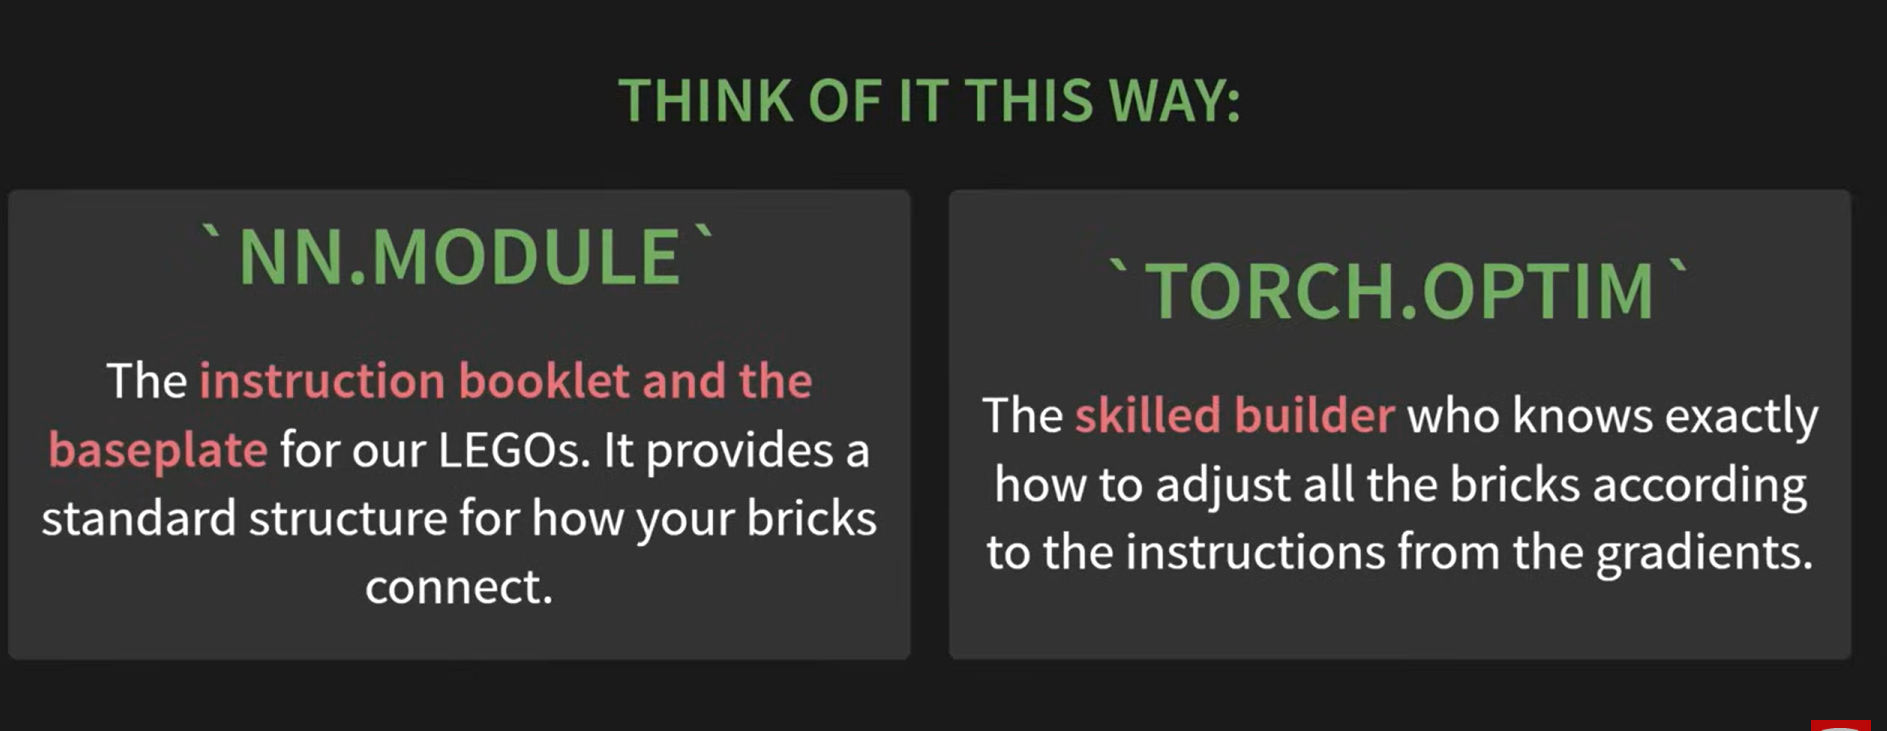

In [ ]:
import torch.nn as nn

class Linear_reg(nn.Module):
  def __init__(self, in_features, out_features):
    super().__init__()
    self.liear_layer = nn.Linear(in_features, out_features)

  def forward(self, x):
    return self.liear_layer(x)

model= Linear_reg(in_features=1,out_features=1)

In [ ]:
print(model)

Linear_reg(
  (liear_layer): Linear(in_features=1, out_features=1, bias=True)
)


In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(),lr=0.01)
loss_fn = nn.MSELoss()

In [ ]:
epochs = 100

for epoch in range(epochs):
  ## forward pass
  y_hat = model(X)

  ## LOSS calculation
  loss = loss_fn(y_hat, y_true)

  ####  ----------------this is 3 LINE mantra
  optimizer.zero_grad()     # 1. Zero the gradients
  loss.backward()           # 2. Computing gradients
  optimizer.step()          # 3. Update parameters

  if epoch % 10 ==0:
    print(f'Epoch {epoch:02d}: Loss={loss.item():0.4f}')

Epoch 00: Loss=1.1114
Epoch 10: Loss=0.8779
Epoch 20: Loss=0.6986
Epoch 30: Loss=0.5659
Epoch 40: Loss=0.4629
Epoch 50: Loss=0.3761
Epoch 60: Loss=0.3011
Epoch 70: Loss=0.2380
Epoch 80: Loss=0.1860
Epoch 90: Loss=0.1439


In [ ]:
with torch.no_grad():
  model.eval()
  preds=model(X,)